In [ ]:
from itertools import permutations

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import sklearn
from shapely.geometry import LineString, Point

ox.settings.use_cache = True
ox.settings.log_console = True

place = "La Reina, Santiago Metropolitan Region, Chile"

G = ox.graph_from_place(
    place,
    network_type="drive",  # drive | walk | bike | all
    simplify=True,
)

# G = ox.add_edge_speeds(G)
# G = ox.add_edge_travel_times(G)

In [ ]:
def compute_shortest_paths(G, nodes_list, criteria="distance"):
    """
    Compute shortest paths between all pairs of nodes in nodes_list.

    Parameters
    ----------
    G : networkx.MultiDiGraph
        Street graph with ``weight`` and ``length`` edge attributes.
    nodes_list : list
        Node IDs to compute paths between.
    criteria : str, optional
        Routing criteria, default ``"distance"``.

    Returns
    -------
    dict
        Keys are ``(source, sink)`` tuples, values are dicts with
        ``"distance"`` (float, meters) and ``"path"`` (list of node IDs).
        Pairs with no valid path are skipped.
    """
    shortest_path_dict = {}
    for source_node in nodes_list:
        for sink_node in nodes_list:
            path = ox.shortest_path(G, source_node, sink_node, weight="weight")
            try:
                distance = round(nx.path_weight(G, path, weight="length"), 2)
                shortest_path_dict[(source_node, sink_node)] = {
                    "distance": distance,
                    "path": path,
                }
            except:
                pass
    return shortest_path_dict


def create_simplified_graph(shortest_path_dict):
    """
    Build a simplified DiGraph from precomputed shortest path distances.

    Parameters
    ----------
    shortest_path_dict : dict
        Output of ``compute_shortest_paths``.

    Returns
    -------
    networkx.DiGraph
        Directed graph where each edge weight is the shortest path distance
        between two nodes. Self-loops are excluded.
    """
    G = nx.DiGraph()
    for key, values in shortest_path_dict.items():
        if key[0] == key[1]:
            continue
        G.add_edge(key[0], key[1], weight=values["distance"])
    return G


def projected_graph(G):
    """
    Project a street graph to a local UTM CRS (meters).

    Parameters
    ----------
    G : networkx.MultiDiGraph
        Street graph in EPSG:4326.

    Returns
    -------
    networkx.MultiDiGraph
        Projected graph in meters.
    """
    return ox.project_graph(G)


def map_point_to_closest_edge_node(G, nodes_dict):  # , lat=-33.44341785083225, lon=-70.5667162):
    """
    Snap arbitrary points to their closest street edge, inserting them as new
    nodes by splitting that edge into two segments.

    Parameters
    ----------
    G : networkx.MultiDiGraph
        Street graph in EPSG:4326 (OSMnx format).
    nodes_dict : dict
        Points to insert. Each value must have:
        ``x`` (lon), ``y`` (lat), ``source`` (bool), ``sink`` (bool).
        Source nodes get ID=1, sink nodes ID=-1, others get max(nodes)+1.

    Returns
    -------
    networkx.MultiDiGraph
        Updated graph in EPSG:4326 with new nodes inserted and original
        edges replaced by two split segments preserving all edge attributes.
    """
    # Call projected_graph
    G_proj = projected_graph(G)
    # Convert graph edges to a GeoDataFrame (projected, in meters)
    edges = ox.graph_to_gdfs(G_proj, nodes=False)

    added_nodes_id = []
    for key, values in nodes_dict.items():
        lat, lon = values["y"], values["x"]
        # Create a GeoDataFrame for the point in WGS84 (lat/lon)
        gdf_point = gpd.GeoDataFrame(
            geometry=[Point(lon, lat)],  # NOTE: Point expects (lon, lat)
            crs="EPSG:4326",
        )

        # Project the point to the same CRS as the projected graph (meters)
        gdf_point_proj = gdf_point.to_crs(G_proj.graph["crs"])
        point_proj = gdf_point_proj.geometry.iloc[0]

        # # Convert graph edges to a GeoDataFrame (projected, in meters)
        # edges = ox.graph_to_gdfs(G_proj, nodes=False)

        # Compute the distance from the point to every edge geometry
        edges["dist"] = edges.geometry.distance(point_proj)

        # Select the closest edge (minimum distance)
        closest_edge = edges.loc[edges["dist"].idxmin()]

        # Extract edge identifiers (MultiDiGraph uses u, v, key)
        u, v, key = closest_edge.name
        edge_geom = closest_edge.geometry

        # Compute the closest point on the edge geometry to the input point
        # This is the projection of the point onto the LineString
        snap_point = edge_geom.interpolate(edge_geom.project(point_proj))

        # Create a new node ID (simple unique ID strategy)
        if values["source"]:
            new_node_id = 1
        elif values["sink"]:
            new_node_id = -1
        else:
            new_node_id = max(G_proj.nodes) + 1

        added_nodes_id.append(new_node_id)

        # Add the new node at the snapped location
        G_proj.add_node(
            new_node_id,
            x=snap_point.x,
            y=snap_point.y,
        )

        # Create new geometries by splitting the original edge at the snap point
        # First segment: from u -> snap point
        line_u = LineString(
            [
                (G_proj.nodes[u]["x"], G_proj.nodes[u]["y"]),
                (snap_point.x, snap_point.y),
            ]
        )

        # Second segment: from snap point -> v
        line_v = LineString(
            [
                (snap_point.x, snap_point.y),
                (G_proj.nodes[v]["x"], G_proj.nodes[v]["y"]),
            ]
        )

        # Copy original edge attributes to preserve metadata (speed, highway, etc.)
        edge_attrs = G_proj[u][v][key].copy()

        # Remove old geometry to avoid conflicts
        edge_attrs.pop("geometry", None)

        # Update edge attributes for the first segment
        edge_attrs["length"] = line_u.length  # length in meters
        edge_attrs["geometry"] = line_u

        # Remove the original edge (u, v) before inserting the split edges
        G_proj.remove_edge(u, v, key)

        # Add new edge from u -> new_node
        G_proj.add_edge(
            u,
            new_node_id,
            **edge_attrs,
        )

        # Prepare attributes for the second segment
        edge_attrs_v = edge_attrs.copy()
        edge_attrs_v["length"] = line_v.length
        edge_attrs_v["geometry"] = line_v

        # Add new edge from new_node -> v
        G_proj.add_edge(
            new_node_id,
            v,
            **edge_attrs_v,
        )

    G_final = ox.project_graph(G_proj, to_crs="EPSG:4326")
    return G_final, added_nodes_id


def find_optimal_route(shortest_path_dict, source, sink, intermediate_nodes):
    """
    Find the optimal visiting order for all intermediate nodes using brute force.
    Fixed start (source) and fixed end (sink), no return to start.

    Parameters
    ----------
    shortest_path_dict : dict
        Output of compute_shortest_paths. Keys are (source, sink) tuples,
        values are dicts with "distance" and "path".
    source : int
        ID of the starting node (driver's first pickup).
    sink : int
        ID of the ending node (driver's home).
    intermediate_nodes : list
        IDs of all friends' nodes to visit in between.

    Returns
    -------
    best_order : list
        Optimal sequence of node IDs: [source, ..., sink].
    best_distance : float
        Total distance of the optimal route in meters.
    """
    best_distance = float("inf")
    best_order = None

    for perm in permutations(intermediate_nodes):
        # Full route: source → all friends in some order → sink
        full_route = [source] + list(perm) + [sink]

        # Check all consecutive pairs exist in shortest_path_dict
        try:
            total_distance = sum(
                shortest_path_dict[(full_route[i], full_route[i + 1])]["distance"]
                for i in range(len(full_route) - 1)
            )
        except KeyError:
            # Skip routes where a path between two nodes doesn't exist
            continue

        if total_distance < best_distance:
            best_distance = total_distance
            best_order = full_route

    return best_order, best_distance


In [48]:
nodes_dict = {
    "TEO": {"source": False, "sink": False, "y": -33.44230868573651, "x": -70.57211041349215},
    "Malu": {"source": False, "sink": True, "y": -33.44341785083225, "x": -70.5667162},
    "Reg_Civil": {"source": False, "sink": False, "y": -33.45048, "x": -70.54276},
    "Ram_lav": {"source": False, "sink": False, "y": -33.44033665554887, "x": -70.56704991349216},
    "Zamorano": {"source": True, "sink": False, "y": -33.428560774159344, "x": -70.53765037301235},
    "La_pizarra": {
        "source": False,
        "sink": False,
        "y": -33.438409949072835,
        "x": -70.56474536067596,
    },
}

G_final, nodes_lista = map_point_to_closest_edge_node(G, nodes_dict)


compute_shortest_paths(G_final, nodes_lista)

/opt/miniconda3/envs/friendly-route/lib/python3.10/site-packages/osmnx/routing.py:338: UserWarning: The attribute 'weight' is missing or null on some edges.
  _verify_edge_attribute(G, weight)


TypeError: type list doesn't define __round__ method

In [ ]:
nodes_dict = {
    "TEO": {"source": False, "sink": False, "y": -33.44230868573651, "x": -70.57211041349215},
    "Malu": {"source": False, "sink": True, "y": -33.44341785083225, "x": -70.5667162},
    "Reg_Civil": {"source": False, "sink": False, "y": -33.45048, "x": -70.54276},
    "Ram_lav": {"source": False, "sink": False, "y": -33.44033665554887, "x": -70.56704991349216},
    "Zamorano": {"source": True, "sink": False, "y": -33.428560774159344, "x": -70.53765037301235},
    "La_pizarra": {
        "source": False,
        "sink": False,
        "y": -33.438409949072835,
        "x": -70.56474536067596,
    },
}

G_final, nodes_lista = map_point_to_closest_edge_node(G, nodes_dict)

orig = 1
dest = -1


# route = ox.shortest_path(G_final, orig, dest, weight="length")

# distance = round(nx.path_weight(G_final, route, weight="length") / 1000, 2)

# source = 1  # Malu
# sink = -1  # Zamorano

# intermediate_nodes = [
#     node_id for node_id, values in nodes_dict.items() if not values["source"] and not values["sink"]
# ]

# best_order, best_distance = find_optimal_route(shortest_path_dict, source, sink, intermediate_nodes)

# print(f"Optimal order: {best_order}")
# print(f"Total distance: {round(best_distance / 1000, 2)} km")

[12796417696, -1, 12796417697, 12796417698, 1, 12796417699]


In [33]:
print(distance)

3.85


The distance is: 0.0 kms


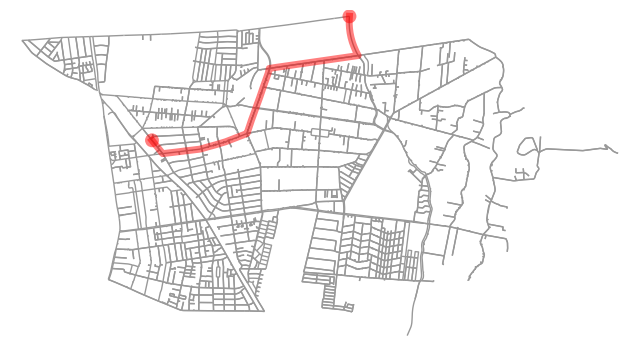

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [34]:
import osmnx as ox

print(f"The distance is: {round(distance / 1000, 2)} kms")

ox.plot_graph_route(
    G_final, route, route_linewidth=5, route_color="red", node_size=0, bgcolor="white"
)

In [83]:
print(G, G_final)

MultiDiGraph with 3062 nodes and 6579 edges MultiDiGraph with 3066 nodes and 6583 edges


In [85]:
G_final.nodes[1]

{'y': np.float64(-33.442338126896296), 'x': np.float64(-70.5723818547006)}

In [ ]:
import folium
import osmnx as ox

place = "La Reina, Santiago Metropolitan Region, Chile"

G = ox.graph_from_place(place, network_type="drive", simplify=True)

# centro del mapa
lat, lon = ox.geocode(place)

m = folium.Map(location=[lat, lon], zoom_start=13, tiles="OpenStreetMap")


# agregar la red
folium.GeoJson(ox.graph_to_gdfs(G, nodes=False).geometry).add_to(m)
m.save("map.html")
# m

In [ ]:
distance = nx.path_weight(G, route, weight="length")

In [127]:
G2 = nx.DiGraph()
for key, values in ss.items():
    if key[0] == key[1]:
        continue
    else:
        G2.add_edge(key[0], key[1], weight=values["distance"])

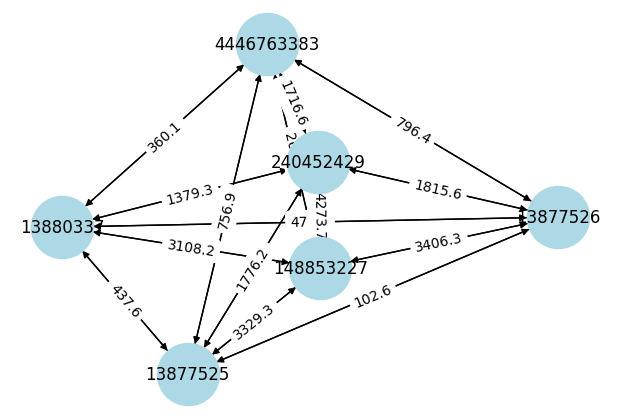

In [128]:
plt.figure(figsize=(6, 4))

pos = nx.spring_layout(G2, seed=42)

nx.draw(
    G2,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    arrows=True,
)

edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G2.edges(data=True)}

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()